In [ ]:
import os
import numpy as np
from matplotlib import pyplot as plt
from scipy.spatial import KDTree
from scipy.ndimage import binary_erosion, binary_dilation
from osgeo import gdal
from pathlib import Path
from typing import Union
gdal.UseExceptions()

In [ ]:
def read_file(filename: Union[str, Path]) -> dict:
        """Reads a TIFF file and extracts depth data and metadata.

        Returns
        ------
          dict
                : properties (filename : str,
                            type: 'raster',
                            depth_data : np.array,
                            metadata : dict)

        """

        with gdal.Open(str(filename)) as ds:
            if not ds:
                raise RuntimeError(
                    f"GDAL failed to open TIFF file: '{filename}'")

            # Read raster data from TIFF
            depth_band = ds.GetRasterBand(1)
            if not depth_band:
                raise RuntimeError(
                    f"Error retrieving depth information from {filename}.")

            ndv_value = depth_band.GetNoDataValue()
            raw_depth_data = depth_band.ReadAsArray()
            depth_gt = ds.GetGeoTransform()
            resolution = depth_gt[1]
            if resolution < 1:
                print(f"WARNING: detected resolution value is <= 1"
                      f"\n Setting resolution value to 1")
                resolution = 1

            depth_data = raw_depth_data

            return {'data': depth_data,
                    'filename': Path(filename).name,
                    'filetype': 'raster',
                    'metadata': {'ndv_value': ndv_value,
                                 'resolution': resolution,
                                 'full_path': filename,
                                 'geotransform': depth_gt}
                }


def raster_to_points(raster_data: dict,
                     remove_ndv: bool = True) -> np.ndarray:
    """
    Transforms raster 2d data into array of points (x, y, depth)

    Parameters
    ----------
    raster_data : dict
        A dictionary representing surface elevation or bathymetry depth.
        Expected to be numeric (e.g., float, int).
    remove_ndv : bool, optional
        If True, removes points with no-data values (NDV) from the output. Defaults to True.

    Returns
    -------
    np.ndarray
        A NumPy array with 3 columns (x, y, depth) and rows corresponding to
        the number of valid points in the original raster.

    """

    elev = raster_data["data"].copy()
    depth_gt = raster_data["metadata"]["geotransform"]
    resolution = raster_data["metadata"]["resolution"]

    # Get raster dimensions
    rows, cols = elev.shape

    # Create coordinate arrays based on geotransform
    x_coords = depth_gt[0] + (np.arange(cols) * depth_gt[1]) + (resolution / 2)
    y_coords = depth_gt[3] + (np.arange(rows) * depth_gt[5]) + (resolution / 2)

    # Create meshgrid of coordinates and flatten it along with the depth values
    x_mesh, y_mesh = np.meshgrid(x_coords, y_coords)
    points = np.column_stack((x_mesh.flatten(), y_mesh.flatten(), elev.flatten()))

    if remove_ndv:
        ndv = raster_data["metadata"]["ndv_value"]
        if ndv == np.nan:
            valid_mask = ~np.isnan(points[:, 2])
        else:
            valid_mask = points[:, 2] != ndv
        points = points[valid_mask]

    points_dataset = points

    return points_dataset

def show_depth(points_dataset: np.ndarray, title: Union[str, None] = None):
        """
        Plots the depth for visualization
        Parameters
        ----------
        points_dataset: np.ndarray
            A NumPy array with 3 columns (x, y, depth) representing the points.
        title: str
            Custom plot title
            Default is filename with linespacing and resolution information

        Returns
        -------
        none

        """
        fig, ax1 = plt.subplots(figsize=(20,10))
        res = points_dataset["metadata"]['resolution']
        if points_dataset["filetype"] == 'raster':
            im = ax1.imshow(points_dataset["data"], cmap='terrain', aspect='equal')
            shape_0 = points_dataset["data"].shape[0]
            shape_1 = points_dataset["data"].shape[1]
            fig.colorbar(im, label='Depth (m)')
            locs = ax1.get_xticks()
            ax1.set_xticks(locs)
            ax1.set_xticklabels([str(int(x * res)) for x in locs])
            locs = ax1.get_yticks()
            ax1.set_yticks(locs)
            ax1.set_yticklabels([str(int(y * res)) for y in locs])
            ax1.tick_params(axis='x', labelrotation=90)
            ax1.set_xlim(left=0, right=shape_1)
            ax1.set_ylim(top=0, bottom=shape_0)
        elif points_dataset["filetype"] == 'points':
            x = points_dataset[:, 0]
            y = points_dataset[:, 1]
            depth = points_dataset[:, 2]
            sc = ax1.scatter(x, y, c=depth, cmap='terrain', marker='.', s=1)
            fig.colorbar(sc, label='Depth (m)')
            shape_0 = int((np.max(y) - np.min(y)) / res)
            shape_1 = int((np.max(x) - np.min(x)) / res)
        else:
            raise ValueError(f"Unrecognized file type for plotting: {points_dataset['filetype']}")
        ax1.set_xlabel("West-East (m)")
        ax1.set_ylabel("North-South (m)")
        if title is None:
            fn = Path(points_dataset["filename"]).name
            title = f"{fn} at {res}m resolution"
        ax1.set_title(f"""
                    Surface:{title} at {res}m resolution
                    Dimensions: {shape_0 * res / 1000}km by {shape_1 * res / 1000}km
                        """)

--2026-02-21 17:31:36--  https://data.ngdc.noaa.gov/platforms/ocean/nos/coast/H12001-H14000/H13060/BAG/H13060_MB_4m_MLLW_3of3.bag
Resolving data.ngdc.noaa.gov (data.ngdc.noaa.gov)... 140.172.190.7, 140.172.190.8, 2610:20:8800:3c0c::8, ...
Connecting to data.ngdc.noaa.gov (data.ngdc.noaa.gov)|140.172.190.7|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9557715 (9.1M)
Saving to: ‘H13060_MB_4m_MLLW_3of3.bag’

H13060_MB_4m_MLLW_3 100%[===================>]   9.11M  5.27MB/s    in 1.7s    

2026-02-21 17:31:38 (5.27 MB/s) - ‘H13060_MB_4m_MLLW_3of3.bag’ saved [9557715/9557715]



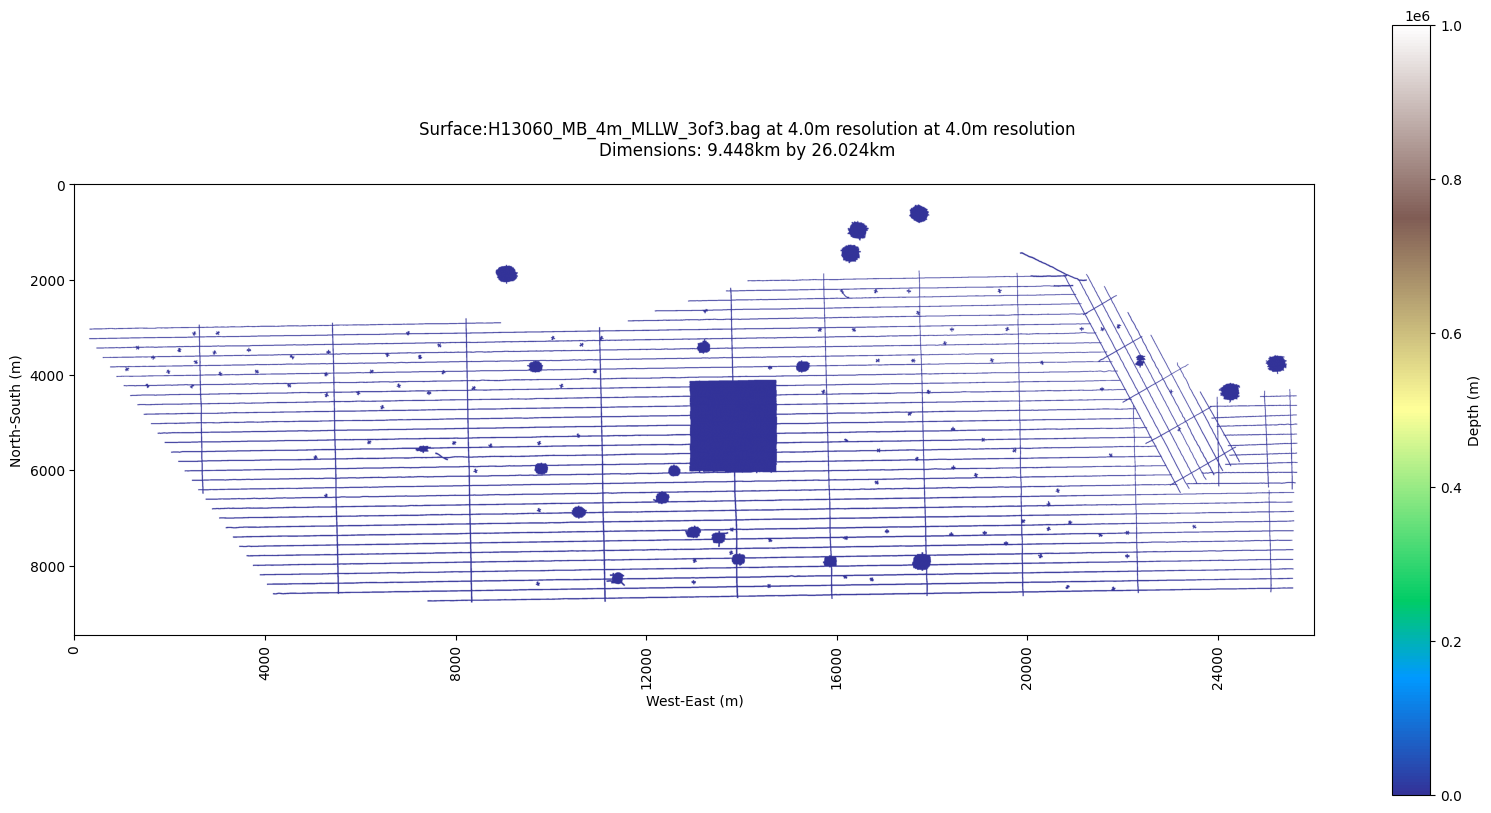

In [ ]:
if os.path.exists('H13060_MB_4m_MLLW_3of3.bag'):
  print('File already found locally, no need to redownload!')
else:
  !wget https://data.ngdc.noaa.gov/platforms/ocean/nos/coast/H12001-H14000/H13060/BAG/H13060_MB_4m_MLLW_3of3.bag
bathy_data = read_file('H13060_MB_4m_MLLW_3of3.bag')
show_depth(bathy_data)

In [ ]:
# reduce the data footprint to reduce line thickness
raw_depth_data = bathy_data['data']
ndv_value = bathy_data['metadata']['ndv_value']

if np.isnan(ndv_value):
    valid_mask = ~np.isnan(raw_depth_data)
else:
    valid_mask = raw_depth_data != ndv_value

current_mask = valid_mask.copy()
starting_count = np.sum(current_mask)
remaining_points = starting_count
point_count = []
slopes = []
curvatures = []
masks = []

while remaining_points/starting_count > 0.1:
    masks.append(current_mask.copy())
    current_mask = binary_erosion(current_mask)
    remaining_points = np.sum(current_mask)
    point_count.append(remaining_points)
    if len(point_count) >= 2:
      slope = point_count[-1] - point_count[-2]
      slopes.append(slope)
    if len(slopes) >= 2:
      curvature = slopes[-1] - slopes[-2]
      curvatures.append(curvature)
    if len(curvatures) >= 2:
      if curvatures[-1] > curvatures[-2]:
        break

developments = binary_dilation(current_mask, iterations=len(slopes))

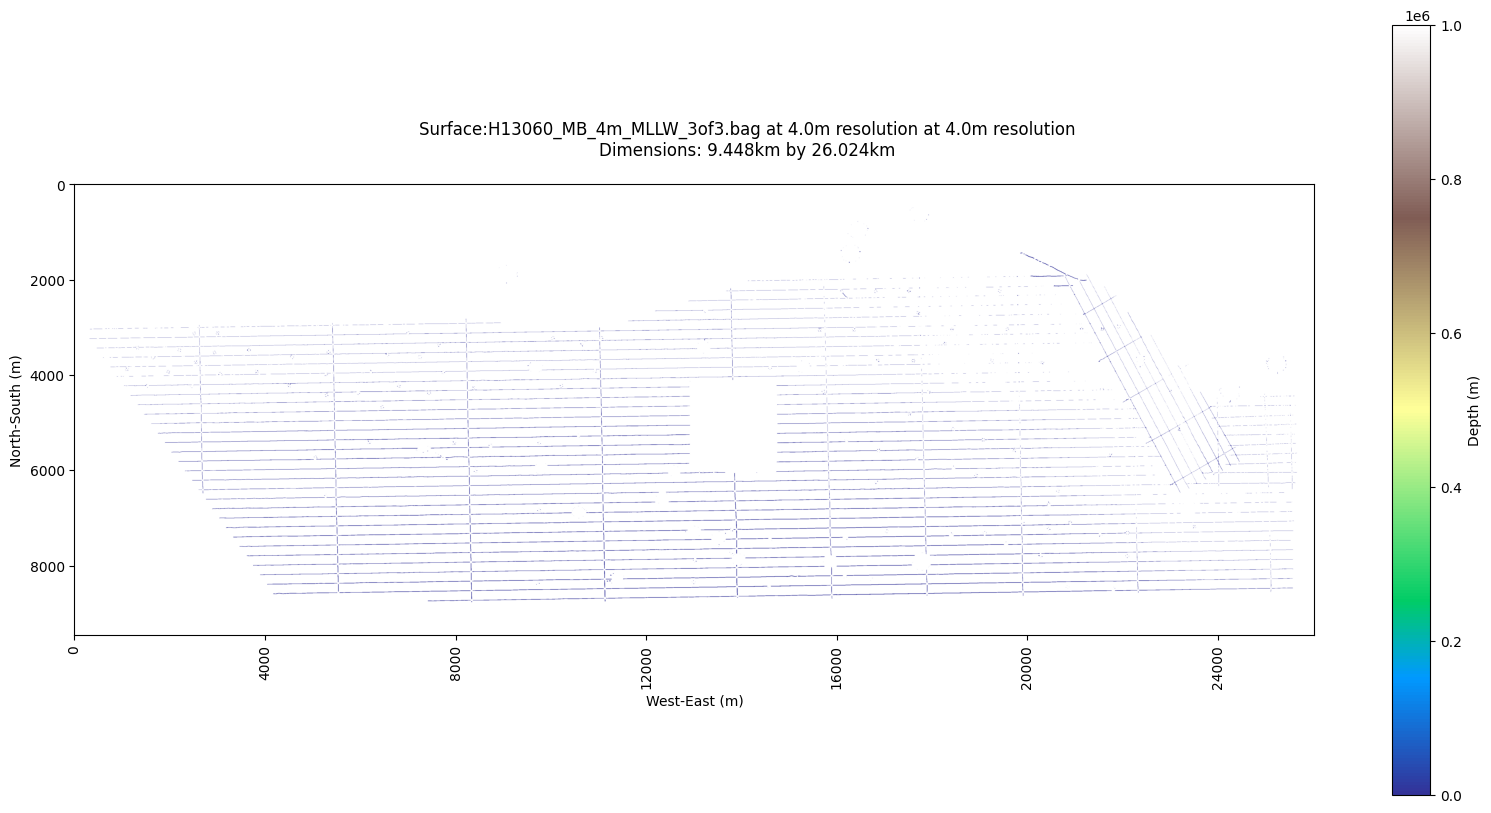

In [ ]:
# let's just keep the lines
line_mask = masks[-2] & ~developments
raw_depth_data[~line_mask] = bathy_data['metadata']['ndv_value']
trimmed_bathy_data = bathy_data.copy()
trimmed_bathy_data['data'] = raw_depth_data
show_depth(trimmed_bathy_data)


In [ ]:
bathy_data_points = raster_to_points(trimmed_bathy_data)

In [ ]:
tree = KDTree(bathy_data_points)
first_neighbor = [np.squeeze(array) for array in tree.query(bathy_data_points, k=[2])]

In [ ]:
line_segments = np.hstack((bathy_data_points, bathy_data_points[first_neighbor[1]]))
line_dir = line_segments[:, 0:2] - line_segments[:, 3:5]
line_len = np.sqrt(line_dir[:,0]**2 + line_dir[:,1]**2)
resolution = bathy_data['metadata']['resolution']
good_segments = np.nonzero(line_len < 1.5*resolution)
filtered_line_segments = line_segments[good_segments]
filtered_line_dir = line_dir[good_segments]

In [ ]:
# Are the same line segments in the set twice?
tmp = np.hstack((filtered_line_segments[:,3:6], filtered_line_segments[:,0:3]))
print(tmp[0])
print(filtered_line_segments[0])


[ 3.20304000e+05  3.36095200e+06 -2.97104645e+00  3.20308000e+05
  3.36095600e+06 -2.96228004e+00]
[ 3.20308000e+05  3.36095600e+06 -2.96228004e+00  3.20304000e+05
  3.36095200e+06 -2.97104645e+00]


In [ ]:
dt = filtered_line_segments.dtype
structured_dtype = [('f{}'.format(i), dt) for i in range(filtered_line_segments.shape[1])]

filtered_line_segments_structured = np.ascontiguousarray(filtered_line_segments).view(structured_dtype)
tmp_structured = np.ascontiguousarray(tmp).view(structured_dtype)

common_segments_structured, idx1, idx2 = np.intersect1d(filtered_line_segments_structured, tmp_structured, return_indices=True)

if len(common_segments_structured) > 0:
    common_segments = common_segments_structured.view(dt).reshape(-1, filtered_line_segments.shape[1])
    print(f"Number of common segments found: {len(common_segments)}")
    print("First 5 common segments (if any):")
    print(common_segments[:5])
else:
    print("No common segments found between filtered_line_segments and tmp.")

Number of common segments found: 190684
First 5 common segments (if any):
[[ 3.03028000e+05  3.35821200e+06 -3.31289506e+00  3.03032000e+05
   3.35821200e+06 -3.31287718e+00]
 [ 3.03032000e+05  3.35821200e+06 -3.31287718e+00  3.03028000e+05
   3.35821200e+06 -3.31289506e+00]
 [ 3.03036000e+05  3.35841200e+06 -3.27899790e+00  3.03040000e+05
   3.35841200e+06 -3.27759480e+00]
 [ 3.03040000e+05  3.35821200e+06 -3.30783272e+00  3.03044000e+05
   3.35821200e+06 -3.30778003e+00]
 [ 3.03040000e+05  3.35841200e+06 -3.27759480e+00  3.03036000e+05
   3.35841200e+06 -3.27899790e+00]]


In [ ]:
print(common_segments)
print(len(common_segments))
print(len(filtered_line_segments))
print(len(idx1))
print(len(idx2))

[[ 3.03028000e+05  3.35821200e+06 -3.31289506e+00  3.03032000e+05
   3.35821200e+06 -3.31287718e+00]
 [ 3.03032000e+05  3.35821200e+06 -3.31287718e+00  3.03028000e+05
   3.35821200e+06 -3.31289506e+00]
 [ 3.03036000e+05  3.35841200e+06 -3.27899790e+00  3.03040000e+05
   3.35841200e+06 -3.27759480e+00]
 ...
 [ 3.28356000e+05  3.35541200e+06 -2.40507174e+00  3.28360000e+05
   3.35541200e+06 -2.40263915e+00]
 [ 3.28356000e+05  3.35581600e+06 -2.21677041e+00  3.28352000e+05
   3.35581600e+06 -2.22040582e+00]
 [ 3.28360000e+05  3.35541200e+06 -2.40263915e+00  3.28356000e+05
   3.35541200e+06 -2.40507174e+00]]
190684
293340
190684
190684


In [ ]:
print(filtered_line_segments[idx1[:3]])
print(filtered_line_segments[idx2[:3]])


[[ 3.03028000e+05  3.35821200e+06 -3.31289506e+00  3.03032000e+05
   3.35821200e+06 -3.31287718e+00]
 [ 3.03032000e+05  3.35821200e+06 -3.31287718e+00  3.03028000e+05
   3.35821200e+06 -3.31289506e+00]
 [ 3.03036000e+05  3.35841200e+06 -3.27899790e+00  3.03040000e+05
   3.35841200e+06 -3.27759480e+00]]
[[ 3.03032000e+05  3.35821200e+06 -3.31287718e+00  3.03028000e+05
   3.35821200e+06 -3.31289506e+00]
 [ 3.03028000e+05  3.35821200e+06 -3.31289506e+00  3.03032000e+05
   3.35821200e+06 -3.31287718e+00]
 [ 3.03040000e+05  3.35841200e+06 -3.27759480e+00  3.03036000e+05
   3.35841200e+06 -3.27899790e+00]]
